Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
VS Code Remote Environment Ready. Workspace: /content/drive/My Drive/DeepLense_GSoC_Data
 Data Pipeline Ready.
 Training: 1200 images
 Validation: 300 images
Training on: cuda
Starting Baseline Training


Epoch 5/5: 100%|██████████| 38/38 [00:03<00:00, 10.27it/s, Loss=0.8606, Acc=55.67%]


Baseline Training Complete!
Model saved to /content/drive/My Drive/DeepLense_GSoC_Data/resnet18_baseline.pth
Running Inference on Validation Set


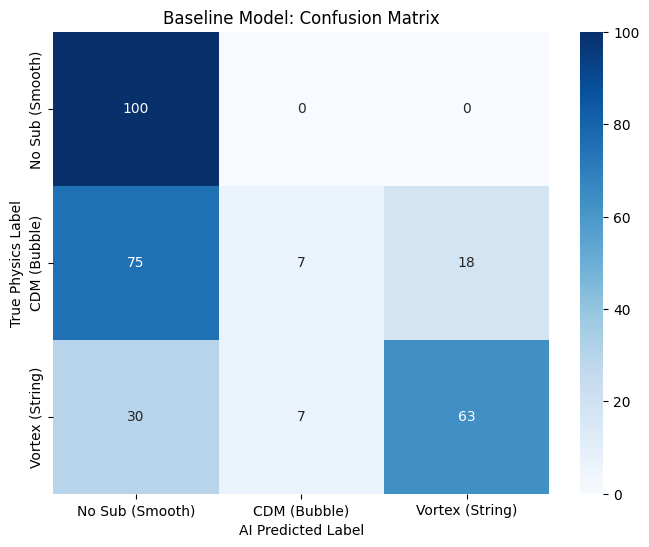


 Classification Report:
                 precision    recall  f1-score   support

No Sub (Smooth)       0.49      1.00      0.66       100
   CDM (Bubble)       0.50      0.07      0.12       100
Vortex (String)       0.78      0.63      0.70       100

       accuracy                           0.57       300
      macro avg       0.59      0.57      0.49       300
   weighted avg       0.59      0.57      0.49       300



In [3]:
import os
import sys

!pip install lenstronomy astropy

from google.colab import drive
drive.mount('/content/drive')
base_dir = "/content/drive/My Drive/DeepLense_GSoC_Data"
print(f"VS Code Remote Environment Ready. Workspace: {base_dir}")

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from sklearn.model_selection import train_test_split

class DeepLenseDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe
        self.root_dir = root_dir
        self.transform = transform
        self.class_map = {'no_sub': 0, 'cdm': 1, 'vortex': 2}

    def __len__(self): 
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = os.path.join(self.root_dir, row['class'], row['filename'])
        image = Image.open(img_path).convert('L')
        if self.transform: image = self.transform(image)
        return image, self.class_map[row['class']]

data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

csv_path = os.path.join(base_dir, "metadata.csv")

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class'])

    train_loader = DataLoader(DeepLenseDataset(train_df, base_dir, transform=data_transform), batch_size=32, shuffle=True)
    val_loader = DataLoader(DeepLenseDataset(val_df, base_dir, transform=data_transform), batch_size=32, shuffle=False)
    
    print(f" Data Pipeline Ready.")
    print(f" Training: {len(train_df)} images")
    print(f" Validation: {len(val_df)} images")
else:
    print("CSV not found.")

#THE BASELINE MODEL (ResNet-18)
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

model = models.resnet18(weights=None) 
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 3)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 5 

print("Starting Baseline Training")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        progress_bar.set_postfix({'Loss': f"{loss.item():.4f}", 'Acc': f"{100 * correct / total:.2f}%"})

print("Baseline Training Complete!")
save_path = os.path.join(base_dir, "resnet18_baseline.pth")
torch.save(model.state_dict(), save_path)
print(f"Model saved to {save_path}")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

model.eval() 
all_preds = []
all_labels = []

print("Running Inference on Validation Set")
with torch.no_grad(): 
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

classes = ['No Sub (Smooth)', 'CDM (Bubble)', 'Vortex (String)']
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Baseline Model: Confusion Matrix')
plt.ylabel('True Physics Label')
plt.xlabel('AI Predicted Label')
assets_dir = os.path.join(base_dir, "assets")
os.makedirs(assets_dir, exist_ok=True)
plt.savefig(os.path.join(assets_dir, "baseline_confusion_matrix.png"), bbox_inches='tight', dpi=300)
plt.show()

print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))